# **Eksperimen Telco Customer Churn**
**Oleh: Muhammad Vatrick Alfaredzi**

Notebook ini berisi tahapan Eksperimen awal yang meliputi:
1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

In [2]:
# Data Loading
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Shape data:", df.shape)
df.head()

Shape data: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## **Exploratory Data Analysis (EDA)**

In [4]:
# Cek info tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Cek missing values
missing = df.isnull().sum()
print('Missing Values per Kolom:')
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

Missing Values per Kolom:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing values: 0


In [6]:
# Ringkasan statistik
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


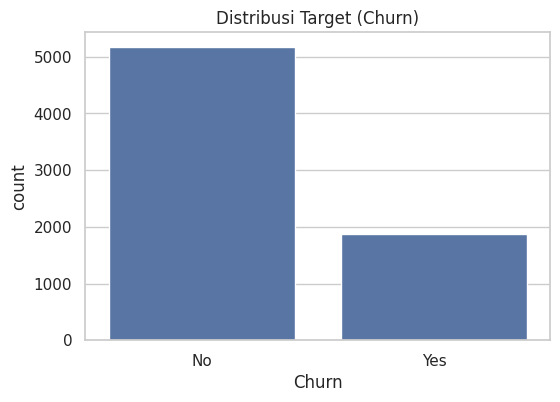

Persentase Churn:
 Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [7]:
# Distribusi Target (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn')
plt.title('Distribusi Target (Churn)')
plt.show()

print("Persentase Churn:\n", df['Churn'].value_counts(normalize=True) * 100)

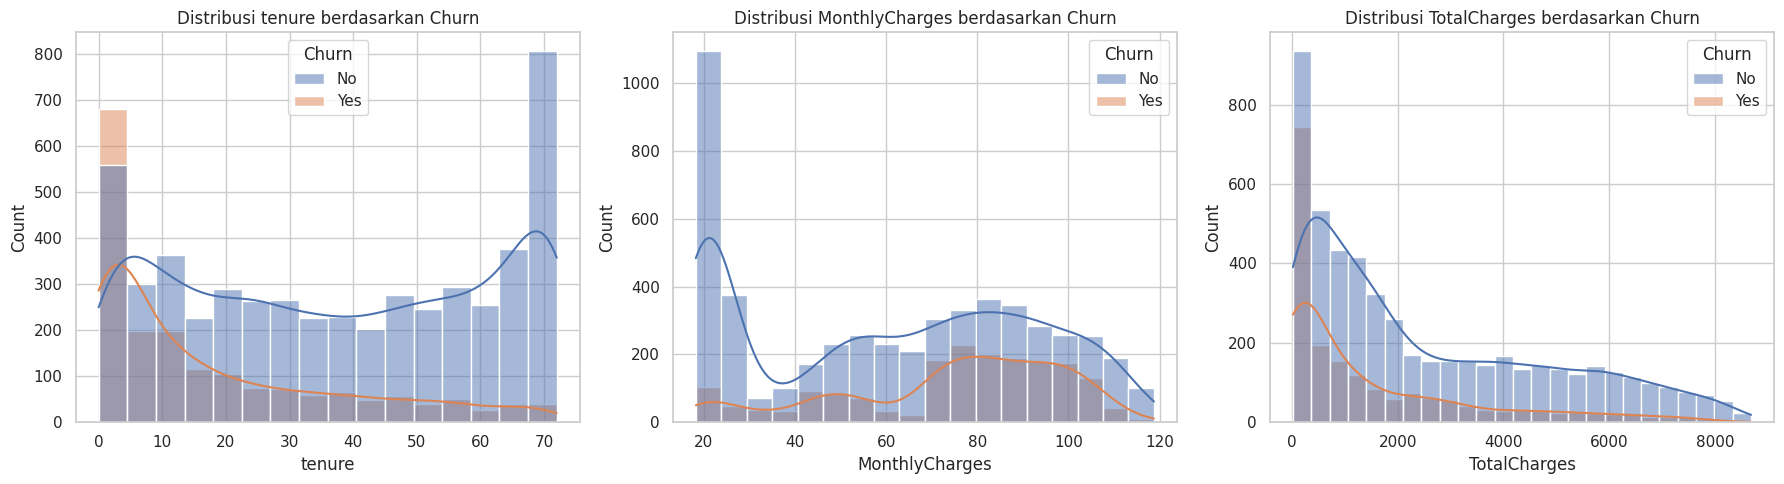

In [8]:
# Fix TotalCharges dari object menjadi numeric sebelum plot numerik
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Distribusi fitur numerik berdasarkan Churn
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=axes[i])
    axes[i].set_title(f'Distribusi {col} berdasarkan Churn')
plt.tight_layout()
plt.show()

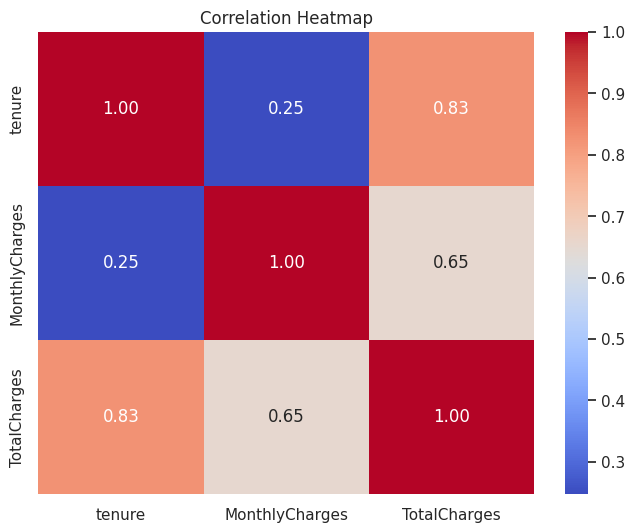

In [9]:
# Correlation Heatmap untuk fitur numerik
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## **Data Preprocessing**

In [10]:
# 1. Menangani Missing Values
print("Missing values sebelum:", df.isnull().sum().sum())
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("Missing values setelah:", df.isnull().sum().sum())

# 2. Drop kolom yang tidak relevan
df = df.drop('customerID', axis=1)

Missing values sebelum: 11
Missing values setelah: 0


In [11]:
# 3. Encoding Fitur Kategorikal
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

categorical_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [12]:
# 4. Feature Scaling
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df[numeric_cols].head()

,tenure,MonthlyCharges,TotalCharges
0,-1.277445,-1.160323,-0.992611
1,0.066327,-0.259629,-0.172165
2,-1.236724,-0.362660,-0.958066
3,0.514251,-0.746535,-0.193672
4,-1.236724,0.197365,-0.938874


In [13]:
# 5. Train-Test Split dan Handle Imbalance (SMOTE)
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Sebelum SMOTE - Jumlah Y=1:", sum(y_train==1), "Jumlah Y=0:", sum(y_train==0))

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Setelah SMOTE - Jumlah Y=1:", sum(y_train_res==1), "Jumlah Y=0:", sum(y_train_res==0))

Sebelum SMOTE - Jumlah Y=1: 1495 Jumlah Y=0: 4139
Setelah SMOTE - Jumlah Y=1: 4139 Jumlah Y=0: 4139


# **Export Data Preprocessed**

In [15]:
# Simpan data preprocessed
import os

output_dir = 'WA_Fn-UseC_-Telco-Customer-Churn_preprocessing'
os.makedirs(output_dir, exist_ok=True)

X_train.to_csv(os.path.join(output_dir, 'X_train.csv'), index=False)
X_test.to_csv(os.path.join(output_dir, 'X_test.csv'), index=False)
y_train.to_csv(os.path.join(output_dir, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(output_dir, 'y_test.csv'), index=False)

print('Data preprocessed berhasil disimpan!')
print(f'Lokasi: {output_dir}/')
print(f'- X_train.csv: {X_train.shape}')
print(f'- X_test.csv: {X_test.shape}')
print(f'- y_train.csv: {y_train.shape}')
print(f'- y_test.csv: {y_test.shape}')

Data preprocessed berhasil disimpan!
Lokasi: WA_Fn-UseC_-Telco-Customer-Churn_preprocessing/
- X_train.csv: (5634, 30)
- X_test.csv: (1409, 30)
- y_train.csv: (5634,)
- y_test.csv: (1409,)
